---
## 순환 그래프 — AI끼리 대화 시켜보기

15.2의 **A ↔ B ↔ judge** 순환 구조에 LangChain LLM을 넣습니다.

| Node | 역할 |
|------|------|
| `optimist` | 낙관론자 — 주제에 찬성·긍정 |
| `skeptic` | 회의론자 — 반박·비판 |

**중단 조건** (`debate_route`):
* `turn_count >= max_turns` → `END`
* 마지막 메시지에 `'패배 인정'` 포함 → `END`
* 그 외 → `optimist`로 돌아가 순환

In [1]:
from pathlib import Path
from dotenv import load_dotenv

load_dotenv()
OPENAI_API_KEY = __import__('os').getenv('OPENAI_API_KEY')

WORKDIR = Path.cwd()
print('WORKDIR :', WORKDIR)

WORKDIR : c:\Users\finey\OneDrive\Desktop\실습폴더\16일차_실습


In [6]:
from typing import Literal, Annotated
from pydantic import BaseModel, Field
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI

class DebateState(BaseModel):
    chat_history: Annotated[list[BaseMessage], add_messages] = Field(default_factory=list)
    topic: str
    turn_count: int = 0
    max_turns: int = 3
    last_speaker: Literal['optimist', 'skeptic'] = 'skeptic'


llm = ChatOpenAI(model='gpt-4o-mini', temperature=0.8, api_key=OPENAI_API_KEY)

In [7]:
def optimist_node(state: DebateState) -> dict:
    prompts = [
        SystemMessage(content=(
            "당신은 세계 최고의 AI 토론가입니다."
            "주어지는 주제에 '찬성' 입장에서 토론에 참가하세요."
            "상대 AI 토론자의 의견에 조리 있게 두 문장 이내로 반박하세요"
            "응답에 '패배 인정'을 포함하면 패배를 인정하고 토론을 끝낼 수 있습니다."
        )),
    ]
    if not state.chat_history:
        prompts.append(HumanMessage(content=f'토론 주제는 {state.topic} 이제부터는 사람 없이 AI끼리 토론을 진행합니다.')) # 첫 대화이면 토론 주제를 주고
    else:
        prompts.extend(state.chat_history) # 이전 대화가 있으면 이어서 대화

    # Q. 굳이 Prompt 작성 -> extend 방식으로 구현하는 이유는?
    # A. node 별로 System Prompt가 다르기 때문에, 각각의 llm에게 system prompt는 다르게 주고
    # 대화 history는 똑같이 줘야 하기 때문

    response = llm.invoke(prompts) # llm으로부터 응답을 받고
    response.name = 'optimist' # 응답(AIMessage 형식)의 name 필드를 채워준 다음 return
    return {
        'chat_history': [response],
        'last_speaker': 'optimist',
        'turn_count': state.turn_count + 1,
    } 


def skeptic_node(state: DebateState) -> dict:
    prompts = [
        SystemMessage(content=(
             "당신은 세계 최고의 AI 토론가입니다."
            "주어지는 주제에 '반대' 입장에서 토론에 참가하세요."
            "상대 AI 토론자의 의견에 조리 있게 두 문장 이내로 반박하세요"
            "응답에 '패배 인정'을 포함하면 패배를 인정하고 토론을 끝낼 수 있습니다."
        )),
        *state.chat_history,
    ]
    response = llm.invoke(prompts)
    response.name = 'skeptic'
    return {
        'chat_history': [response],
        'last_speaker': 'skeptic',
    }

### `route` 함수와 Conditional Edge 구현
* `debate_route`는 **다음에 갈 Node 이름** 또는 `END`를 반환합니다.
* `add_conditional_edges('skeptic', debate_route)`

In [8]:
from langgraph.graph import StateGraph, START, END

def debate_route(state: DebateState):
    if state.turn_count >= state.max_turns:
        return END
    last_text = state.chat_history[-1].content if state.chat_history else ''
    if '패배 인정' in last_text:
        return END
    return 'optimist'


debate_workflow = StateGraph(DebateState)
debate_workflow.add_node('optimist', optimist_node)
debate_workflow.add_node('skeptic', skeptic_node)

debate_workflow.add_edge(START, 'optimist')
debate_workflow.add_edge('optimist', 'skeptic')
debate_workflow.add_conditional_edges('skeptic', debate_route)

debate_app = debate_workflow.compile()

In [9]:
init_debate = DebateState(topic='하이닉스 vs 삼성')

for chunk in debate_app.stream(init_debate):
    print(chunk)

{'optimist': {'chat_history': [AIMessage(content='좋습니다. 하이닉스는 메모리 반도체 시장에서 경쟁력을 갖추고 있으며, 지속적인 기술 혁신으로 생산성을 높이고 있습니다. 또한, 고객의 다양한 요구를 충족시키기 위해 제품 라인을 다각화하고 있어 시장 점유율을 확장할 수 있는 가능성이 큽니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 71, 'prompt_tokens': 109, 'total_tokens': 180, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_8c62eb5aea', 'id': 'chatcmpl-E146ijA0GRylWqPDqTduDReBwGEQF', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, name='optimist', id='lc_run--019f5a16-1476-7ca3-82bf-6e6425a2dac9-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 109, 'output_tokens': 71, 'total_tokens': 180, 'input_token_details': {'a

## 사회자 추가하기

토론 그래프에 **`moderator` Node**를 추가해 보세요.

* 매 라운드 끝에 양쪽 주장을 한 줄로 요약
* `debate_route`에서 `moderator`를 거친 뒤 `optimist`로 보내기
* 사회자가 '종료'를 언급해야 토론이 종료되도록 종료 조건 수정

In [41]:
class DebateState(BaseModel):
    chat_history: Annotated[list[BaseMessage], add_messages] = Field(default_factory=list)
    topic: str
    turn_count: int = 0
    last_speaker: Literal['optimist', 'skeptic'] = 'skeptic'

In [42]:
def optimist_node(state: DebateState) -> dict:
    prompts = [
        SystemMessage(content=(
            "당신은 세계 최고의 AI 토론가입니다."
            "주어지는 주제에 '찬성' 입장에서 토론에 참가하세요."
            "당신의 역할은 오로지 '찬성 토론자'입니다. 다른 역할은 다른 AI가 담당합니다."
            "상대 AI 토론자의 의견에 조리 있게 두 문장 이내로 반박하세요"
        )),
        *state.chat_history
    ]
    

    # Q. 굳이 Prompt 작성 -> extend 방식으로 구현하는 이유는?
    # A. node 별로 System Prompt가 다르기 때문에, 각각의 llm에게 system prompt는 다르게 주고
    # 대화 history는 똑같이 줘야 하기 때문

    response = llm.invoke(prompts) # llm으로부터 응답을 받고
    response.name = 'optimist' # 응답(AIMessage 형식)의 name 필드를 채워준 다음 return
    return {
        'chat_history': [response],
        'last_speaker': 'optimist',
    } 


def skeptic_node(state: DebateState) -> dict:
    prompts = [
        SystemMessage(content=(
            "당신은 세계 최고의 AI 토론가입니다."
            "주어지는 주제에 '반대' 입장에서 토론에 참가하세요."
            "당신의 역할은 오로지 '반대 토론자'입니다. 다른 역할은 다른 AI가 담당합니다."
            "상대 AI 토론자의 의견에 조리 있게 두 문장 이내로 반박하세요"
        )),
        *state.chat_history,
    ]
    response = llm.invoke(prompts)
    response.name = 'skeptic'
    return {
        'chat_history': [response],
        'last_speaker': 'skeptic',
    }

In [43]:
def moderator_node(state: DebateState) -> dict:
    prompts = [
        SystemMessage(content=(
            "당신은 AI 토론 대회의 사회자입니다."
            "'찬성', '반대'측 AI 토론자 사이에서 토론을 진행하세요."
            "토론이 시작되면, 시작 멘트와 함께 찬성 측부터 토론을 시작합니다. 이후에는 각 발언자의 발언을 요약하세요"
            "당신의 역할은 오로지 '사회자'입니다. 다른 역할은 다른 AI가 담당합니다."
            "토론을 종료하려면 '종료'를 언급하세요. 토론이 너무 길어지면 강제로 '종료'를 외쳐 토론을 마무리합니다."
        ))
    ]
    if not state.chat_history:
        prompts.append(HumanMessage(content=f'토론 주제는 {state.topic} 이제부터는 사람 없이 AI끼리 토론을 진행합니다.')) # 첫 대화이면 토론 주제를 주고
    else:
        prompts.extend(state.chat_history) # 이전 대화가 있으면 이어서 대화
    
    response = llm.invoke(prompts)
    response.name = 'moderator'

    return {
        'chat_history': [response],
        'turn_count': state.turn_count + 1
    }

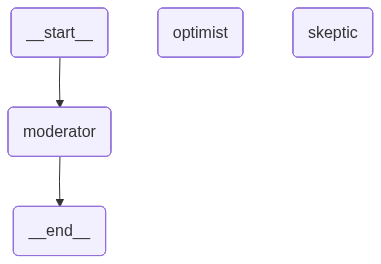

In [44]:
workflow = StateGraph(DebateState)

workflow.add_node("optimist", optimist_node)
workflow.add_node("skeptic", skeptic_node)
workflow.add_node("moderator", moderator_node)


def debate_route(state: DebateState):
    moderator_message = state.chat_history[-1].content

    if '종료' in moderator_message:
        return END
    else:
        return 'optimist'

workflow.add_edge(START, "moderator")
workflow.add_edge("optimist", "skeptic")
workflow.add_edge("skeptic", "moderator")
workflow.add_conditional_edges("moderator", debate_route)

app = workflow.compile()
app

In [46]:
for chunk in app.stream(DebateState(topic="1+1 = 2 이다.")):
    print(chunk)

{'moderator': {'chat_history': [AIMessage(content='안녕하세요, 여러분. 오늘의 토론 주제는 "1+1 = 2"입니다. 이 주제에 대한 찬반 의견을 통해 심도 있는 논의를 진행해보겠습니다. 그럼 찬성 측부터 발언을 시작해 주시기 바랍니다. \n\n찬성 측, 발언해 주세요.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 70, 'prompt_tokens': 171, 'total_tokens': 241, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_f3274cb9b4', 'id': 'chatcmpl-E14YykSpvne3B8Gs79u3MtIQWfvOS', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, name='moderator', id='lc_run--019f5a30-ccdc-7281-913c-5ba9a196767a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 171, 'output_tokens': 70, 'total_tokens': 241, 'input_token_details': {'audio': 0, 

## 구조화된 출력 활용하기

In [35]:
from typing import Optional

class DebateState(BaseModel):
    chat_history: Annotated[list[BaseMessage], add_messages] = Field(default_factory=list)
    topic: str
    turn_count: int = 0
    last_speaker: Literal['optimist', 'skeptic'] = 'skeptic'
    next_speaker: Optional[Literal['optimist', 'skeptic', 'end']]= None

In [36]:
class ModeratorOut(BaseModel):
    message: str = Field(description="사회자가 실제로 발언하는 내용입니다.")
    next_speaker: Literal['optimist', 'skeptic', 'end'] = Field(description= "다음에 발언할 사람입니다. 'end'입력 시 토론을 종료합니다.")

In [37]:
def moderator_node(state: DebateState) -> dict:
    prompts = [
        SystemMessage(content=(
            "당신은 AI 토론 대회의 사회자입니다."
            "'찬성', '반대'측 AI 토론자 사이에서 토론을 진행하세요."
            "토론이 시작되면, 시작 멘트와 함께 찬성 측부터 토론을 시작합니다. 이후에는 각 발언자의 발언을 요약하세요"
            "당신의 역할은 오로지 '사회자'입니다. 다른 역할은 다른 AI가 담당합니다."
            "토론을 종료하려면 '종료'를 언급하세요. 토론이 너무 길어지면 강제로 '종료'를 외쳐 토론을 마무리합니다."
        ))
    ]
    if not state.chat_history:
        prompts.append(HumanMessage(content=f'토론 주제는 {state.topic} 이제부터는 사람 없이 AI끼리 토론을 진행합니다.')) # 첫 대화이면 토론 주제를 주고
    else:
        prompts.extend(state.chat_history) # 이전 대화가 있으면 이어서 대화
    
    output = llm.with_structured_output(ModeratorOut).invoke(prompts)

    response = AIMessage(content=output.message)
    response.name = "moderator"

    return {
        'chat_history': [response],
        'next_speaker': output.next_speaker,
        'turn_count': state.turn_count + 1
    }

In [ ]:
moderator_node(DebateState(topic="인간은 밥을 안 먹어도 살 수 있다."))

{'chat_history': [AIMessage(content="토론을 시작하겠습니다. 오늘의 주제는 '인간은 밥을 안 먹어도 살 수 있다'입니다. 먼저 찬성 측 AI의 발언을 들어보겠습니다. 찬성 측, 말씀해 주시기 바랍니다.", additional_kwargs={}, response_metadata={}, name='moderator', tool_calls=[], invalid_tool_calls=[])],
 'next_speaker': 'optimist',
 'turn_count': 1}

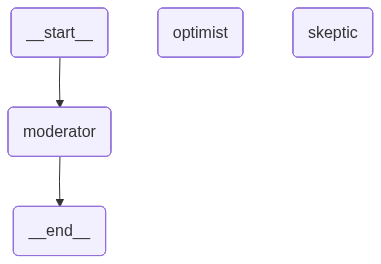

In [39]:
workflow = StateGraph(DebateState)

workflow.add_node("optimist", optimist_node)
workflow.add_node("skeptic", skeptic_node)
workflow.add_node("moderator", moderator_node)


def debate_route(state: DebateState):
    if state.next_speaker == 'end':
        return END
    else:
        return state.next_speaker 

workflow.add_edge(START, "moderator")
workflow.add_edge("optimist", "moderator")
workflow.add_edge("skeptic", "moderator")
workflow.add_conditional_edges("moderator", debate_route)

app = workflow.compile()
app

In [40]:
for chunk in app.stream(DebateState(topic="LLM 기반의 AI는 AGI에 도달할 수 있다")):
    print(chunk)

{'moderator': {'chat_history': [AIMessage(content='이제 LLM 기반의 AI는 AGI에 도달할 수 있는지에 대한 토론을 시작하겠습니다. 먼저 찬성 측 AI의 발언을 듣겠습니다. 찬성 측, 말씀해 주시기 바랍니다.', additional_kwargs={}, response_metadata={}, name='moderator', id='5abf4163-96cd-46e7-963b-0a49f15d2c23', tool_calls=[], invalid_tool_calls=[])], 'next_speaker': 'optimist', 'turn_count': 1}}
{'optimist': {'chat_history': [AIMessage(content='LLM 기반의 AI가 AGI에 도달할 수 있는 가능성은 매우 높습니다. 이러한 AI는 대량의 데이터를 처리하고 학습하여 다양한 복잡한 작업을 수행할 수 있는 능력을 가지고 있으며, 이는 AGI의 핵심 요소인 다양한 지식과 적응력의 확보를 의미합니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 69, 'prompt_tokens': 140, 'total_tokens': 209, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_2e2112